# HMC Clinic: Real-Time Feedback Demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/openquantumhardware/qick/blob/merge-hrl-main/emulator/notebooks/HMC_clinic_feedback_emu.ipynb)

## 0. Colab Setup

Skip this cell if you're running locally with the `qick-venv` kernel (see [`emulator/README.md`](https://github.com/openquantumhardware/qick/blob/merge-hrl-main/emulator/README.md)) -- it's a no-op there. In Google Colab it clones this repo, builds Verilator 5.042 from source, and installs the Python dependencies. **First run takes a few minutes** (compiling Verilator); re-running later cells, or reconnecting to the same runtime, reuses what's already built.

In [1]:
import os
import sys
import pathlib
import subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def run(cmd, **kwargs):
    """Run a shell command, streaming output, and raise loudly on failure.

    Using this instead of bare `!command` / get_ipython().system() so a
    failure here stops the bootstrap immediately with a real traceback,
    instead of silently letting later cells fail with a confusing
    ModuleNotFoundError.
    """
    print(f"+ {cmd}")
    result = subprocess.run(cmd, shell=True, **kwargs)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed (rc={result.returncode}): {cmd}")


if IN_COLAB:
    REPO_URL = "https://github.com/openquantumhardware/qick.git"
    REPO_BRANCH = "merge-hrl-main"
    REPO_DIR = pathlib.Path("/content/qick")

    if not REPO_DIR.exists():
        print(f"Cloning {REPO_URL} @ {REPO_BRANCH} ...")
        run(f"git clone --branch {REPO_BRANCH} --depth 1 {REPO_URL} {REPO_DIR}")
    else:
        # Update in place instead of just reusing whatever was cloned
        # earlier in this runtime (e.g. from opening a previous notebook in
        # the same session) -- otherwise you silently keep running stale
        # code even though the repo has moved on. This is a bootstrap-only
        # clone, so discarding any local state here is safe.
        print(f"{REPO_DIR} already exists -- updating to the latest {REPO_BRANCH} ...")
        os.chdir(REPO_DIR)
        run(f"git fetch --depth 1 origin {REPO_BRANCH}")
        run("git reset --hard FETCH_HEAD")
    os.chdir(REPO_DIR)

    print("Fetching git submodules (Verilator source, AXI/common_cells) ...")
    run("git submodule update --init --recursive --depth 1")

    # Needed whether Verilator itself ends up prebuilt or compiled from
    # source: `make verilate` always invokes g++ (via ccache) to compile the
    # *generated* C++ model for each testbench build, every session. Gated
    # on `ccache` specifically (not pre-installed on a bare Colab image, and
    # the exact thing that broke without this) so that re-running this cell
    # -- or moving on to the next notebook in the same runtime -- doesn't
    # re-run apt every single time.
    import shutil
    if shutil.which("ccache") is None:
        print("Installing build/runtime dependencies (apt) ...")
        run("DEBIAN_FRONTEND=noninteractive apt-get -qq update")
        run(
            "DEBIAN_FRONTEND=noninteractive apt-get -qq install -y "
            "git help2man perl python3 make autoconf g++ flex bison ccache "
            "libgoogle-perftools-dev numactl perl-doc libfl-dev zlib1g-dev"
        )
    else:
        print("Build/runtime dependencies already installed, skipping apt.")

    def verilator_version():
        try:
            r = subprocess.run(["verilator", "--version"], capture_output=True, text=True)
        except FileNotFoundError:
            return ""
        return r.stdout

    if "5.042" not in verilator_version():
        # Fast path: a prebuilt Verilator 5.042, compiled on a real Colab
        # runtime and hosted as a GitHub Release asset -- avoids a ~10-15
        # minute source compile on every session. Falls back to building
        # from source if the download/extraction doesn't work out (e.g. the
        # asset is gone, or a future Colab image isn't binary-compatible).
        PREBUILT_URL = (
            "https://github.com/openquantumhardware/qick/releases/download/"
            "verilator-5.042-colab/verilator-5.042-colab-x86_64.tar.gz"
        )
        prebuilt_ok = False
        print("Trying prebuilt Verilator 5.042 (fast path) ...")
        try:
            run(f"curl -fL -o /tmp/verilator-prebuilt.tar.gz {PREBUILT_URL}")
            run("tar -C /usr/local -xzf /tmp/verilator-prebuilt.tar.gz")
            prebuilt_ok = "5.042" in verilator_version()
        except RuntimeError as e:
            print(f"Prebuilt Verilator download/install failed ({e}); building from source instead.")

        if prebuilt_ok:
            print("Prebuilt Verilator 5.042 installed.")
        else:
            print("Building Verilator 5.042 from source (a few minutes, first run only) ...")
            os.chdir(REPO_DIR / "emulator" / "submodules" / "verilator")
            run("autoconf")
            run("./configure")
            run("make -j$(nproc)")
            run("make install")
            os.chdir(REPO_DIR)
            final_version = verilator_version()
            if "5.042" not in final_version:
                raise RuntimeError(
                    "Verilator build finished but 'verilator --version' still doesn't "
                    f"report 5.042 (got: {final_version!r})"
                )
            print(final_version)
    else:
        print("Verilator 5.042 already installed, skipping build.")

    # Scientific-Python deps only -- NOT jupyter/ipykernel, which would fight
    # with Colab's own kernel runtime. `emulator/requirements.txt` is for the
    # local venv+Jupyter setup (see emulator/README.md); Colab needs a subset.
    print("Installing Python dependencies ...")
    run("pip install numpy scipy matplotlib tqdm")
    run("pip install -e .")

    # Belt-and-suspenders: insert the source dirs directly, so `import qick`
    # works below even if pip's editable-install .pth file isn't picked up by
    # this already-running interpreter (a known Colab quirk).
    for rel in ("qick_lib", "emulator/software"):
        p = str(REPO_DIR / rel)
        if p not in sys.path:
            sys.path.insert(0, p)

    os.chdir(REPO_DIR / "emulator" / "notebooks")

    # Verify right here, in this cell, instead of letting a failure surface
    # one cell later as a confusing ModuleNotFoundError.
    import importlib
    importlib.invalidate_caches()
    try:
        import qick
        print(f"\nColab setup complete. qick {qick.get_version()} importable from {qick.__file__}")
    except ImportError as e:
        raise RuntimeError(
            f"Setup finished but 'import qick' still fails ({e}). "
            f"cwd={pathlib.Path.cwd()}, REPO_DIR contents: {list(REPO_DIR.iterdir())}"
        ) from e
    print(f"Working directory: {pathlib.Path.cwd()}")
else:
    print("Not running in Colab -- skipping clone/build (using the local checkout as-is).")


Not running in Colab -- skipping clone/build (using the local checkout as-is).


In [2]:
import sys
import importlib
import pathlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Local Qick path setup
REPO_ROOT  = pathlib.Path.cwd().parent          # emulator/
sys.path.insert(0,str(REPO_ROOT / '..' / 'qick_lib/'))
# Local QickEmu path setup
source_dir = REPO_ROOT / 'software'
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))
# # Display current sys.path
# print(sys.path)


import qick_emu
importlib.reload(qick_emu)
from qick_emu import QickEmu
from qick.asm_v2 import AveragerProgramV2


## Overview: real-time feedback in QICK

The following demo shows an experiment that demonstrates the QICK tprocv2 capabilities, namely the arithmetic logic capabilities, branching logic, real-time parametric pulse generation, and LFSR based random number generation. The configuration is as follows: channel 0 of the RFSoC is plugged into readout channel 4. A random number is generated with the top 16 bits shifted into a register. The random number is mapped to the amplitude wave parameter of that pulse envelope. The pulse is sent into channel 4, where it is demodulated and averaged, returning an amplitude. The program checks the measured amplitude. If the amplitude is lower than a given amount, it fires a pulse from the channel 2 DAC. TRM manual describing instructions found here: https://github.com/meeg/qick_demos_sho/blob/main/tprocv2/qick_processor_TRM.pdf

In [3]:
# emulator init
# CFG_PATH = REPO_ROOT / 'config' / 'qick_config_216.json'
CFG_PATH = REPO_ROOT / 'config' / 'qick_emu_config.json'
soc      = QickEmu(str(CFG_PATH))
soccfg   = soc.soccfg

# artifact root
ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / 'hmc_clinic_feedback_emu'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

# Master switch — set False to skip Verilator runs and re-plot from existing CSVs
RUN_SIM = True

print(f'REPO_ROOT     : {REPO_ROOT}')
print(f'ARTIFACTS_ROOT: {ARTIFACTS_ROOT}')
print(soccfg)

# Default Path is the artifacts root.
OUT = ARTIFACTS_ROOT

## QICKEmu Auxiliary Functions
def QICKEmu_plot_dac(soc, OUT):
    # DAC waveform
    t_dac, dac = soc.load_dac(OUT)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dac, dac, linewidth=0.8)
    plt.xlabel('time [us]'); plt.ylabel('DAC value'); plt.title('DAC output')
    plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

def QICKEmu_plot_all_dacs(soc_emu, OUT):
    # DAC waveform
    t_dac_ch0, dac_ch0 = soc_emu.load_dac(emu_dir=OUT, gen_ch=0, absolute_time=True)
    t_dac_ch1, dac_ch1 = soc_emu.load_dac(emu_dir=OUT, gen_ch=1, absolute_time=True)    

    plt.figure(figsize=(10, 3))

    plt.plot(t_dac_ch0, dac_ch0, linewidth=0.8)
    plt.plot(t_dac_ch1, dac_ch1, linewidth=0.8)

    plt.xlabel('time [us]'); plt.ylabel('DAC value'); plt.title('DAC output')
    plt.grid(True, ls=':'); plt.tight_layout(); plt.show()


QICK library version mismatch: 0.2.366 remote (the board), 0.2.88 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


REPO_ROOT     : /home/larnaldi/git/emu_v1.2.0/emulator
ARTIFACTS_ROOT: /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/hmc_clinic_feedback_emu
QICK running on QICKEmu, software version 0.2.366

Firmware configuration (built Fri Sep 4 2026):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	3 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is QICKEmu DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is QICKEmu DAC port 1
	2:	axis_sg_mux8_v1 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, bl

In [4]:
from qick.tprocv2_assembler import Assembler

def pstr2asm_inst(self, pstr_lst):
    pstr = '\n'.join(pstr_lst) + '\n'
    asm_dict, labels = Assembler.str_asm2list(pstr)
    for label, addr in labels.items():
        if addr != label:   # skip pre-defined assembler symbols (e.g. 's15': 's15')
            self.label(label)
    for instr in asm_dict:
        self.asm_inst(instr)

# -----------------------------------------------------------------------------
# FIXED MACROS: Inject raw dictionaries to bypass isolated label parsing errors
# -----------------------------------------------------------------------------
def NOP(self):
    self.label('END_SETUP')

def JUMP(self, label):
    self.asm_inst({'CMD': 'JUMP', 'LABEL': label})

def CALL(self, label, cond=None):
    inst = {'CMD': 'CALL', 'LABEL': label}
    if cond is not None:
        inst['IF'] = cond
    self.asm_inst(inst)

def exitREP(self):
    self.label('exitREP')

def SETUP_PULSE(self, cfg): 
    pstr_lst = [
        f'REG_WR w_gain imm #{str(cfg["gain"])}',
        f'REG_WR w_phase imm #{self.deg2reg(cfg["phase"], gen_ch=cfg["gen_ch"])}',
        f'REG_WR w_env imm #0',
        f'REG_WR w_length imm #{self.us2cycles(cfg["pulse_len"], gen_ch=cfg["gen_ch"])}',
        f'REG_WR w_conf imm #9',
        f'REG_WR w_freq imm #{self.freq2reg(cfg["freq"], gen_ch=cfg["gen_ch"])}',
        'WMEM_WR [&0]'
    ]
    pstr2asm_inst(self, pstr_lst)

def SETUP_FEED(self):
    pstr_lst = [
        f'REG_WR w_gain imm #{str(15000)}',
        f'REG_WR w_phase imm #{self.deg2reg(90, gen_ch=2)}',
        f'REG_WR w_env imm #0',
        f'REG_WR w_length imm #{self.us2cycles(0.1, gen_ch=2)}',
        f'REG_WR w_conf imm #9',
        f'REG_WR w_freq imm #{self.freq2reg(1000, gen_ch=2)}',
        'WMEM_WR [&1]'
    ]
    pstr2asm_inst(self, pstr_lst)

def LFSR_sub(self):
    pstr_lst = [
        'LFSR:',
        'REG_WR r26 op -op(s1)',
        'REG_WR r28 op -op(MSH r26)',
        'RET',
    ]
    pstr2asm_inst(self, pstr_lst)

def set_wport_on(self):
    pstr_lst = ['WPON:', 'REG_WR w_gain imm #32766', 'WMEM_WR [&0]', 'RET']
    pstr2asm_inst(self, pstr_lst)

def set_wport_off(self):
    pstr_lst = ['WPOFF:', 'REG_WR w_gain imm #0', 'WMEM_WR [&0]', 'RET']
    pstr2asm_inst(self, pstr_lst)

def cond_out(self):
    # External CALL targets (LFSR, WPON, WPOFF) are not in this string's label_dict,
    # so they must be injected via self.asm_inst to be resolved at link time.
    pstr2asm_inst(self, ['CONDOUT:'])
    CALL(self, 'LFSR')
    pstr2asm_inst(self, ['REG_WR r28 op -op(r28 SR #5)', 'TEST -op(r28 AND #8) -uf'])
    CALL(self, 'WPON', cond='NZ')
    CALL(self, 'WPOFF', cond='Z')
    pstr2asm_inst(self, ['TEST -op(r28) -uf', 'RET'])

def rand_amp(self):
    pstr2asm_inst(self, ['RANDAMP:'])
    CALL(self, 'LFSR')
    pstr2asm_inst(self, ['REG_WR w_gain op -op(ABS r28)', 'WMEM_WR [&0]', 'RET'])

def read_and_jump(self):
    pstr2asm_inst(self, ['THRES:', 'REG_WR r31 op -op(r1)', 'TEST -op(r31 - #500) -uf'])
    CALL(self, 'playPULSE2', cond='Z')
    pstr2asm_inst(self, ['RET'])

def playPULSE1(self, port): 
    pstr2asm_inst(self, ['playPULSE1:', f'WPORT_WR p{port} wmem [&0]', 'RET'])

def playPULSE2(self, port): 
    pstr2asm_inst(self, ['playPULSE2:', f'WPORT_WR p{port} wmem [&1]', 'RET'])

In [5]:
'''
Feedback
'''

class feedback_test(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        shots = cfg['shots']
        gain = cfg['gain']
        feed_ch = cfg['feed_ch']

        self.declare_gen(ch=gen_ch)
        self.declare_gen(ch=feed_ch)

        self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['freq'], gen_ch=gen_ch)

        self.add_pulse(ch=gen_ch, name="mypulse", freq=cfg['freq'], phase=0,
                       length=cfg['pulse_len'], style="const", mode="oneshot",
                       stdysel="zero", gain=gain)
        
        self.add_pulse(ch=feed_ch, name="feedpulse", freq=1000, phase=0,
                       length=0.5, style="const", mode="oneshot",
                       stdysel="zero", gain=gain)

        cfg['gain'] = 32766
        
        SETUP_PULSE(self, cfg)
        
        # FIXED: Tell it to jump to the renamed label
        JUMP(self, "END_SETUP")
        
        playPULSE1(self, gen_ch)
        playPULSE2(self, feed_ch)

        fb_labels = [LFSR_sub, set_wport_on, set_wport_off, cond_out, read_and_jump, rand_amp]
        for label in fb_labels:
            label(self)
        
        NOP(self) # This now drops the 'END_SETUP:' label
        self.add_loop("ShotLoop", shots)

        # Initialize the random number generator with a seed
        self.write_reg(dst='s_rand', src=987654321)

    def _body(self, cfg):

        # Use the call command and labels used in routines to call functions. First setup random amplitude or 
        # conditional out experiment
        
        #CALL(self, 'CONDOUT') # uncomment for conditional out experiment
        CALL(self, 'RANDAMP') 

        CALL(self, 'playPULSE1')

        #call readout
        self.trigger(ros=[cfg['ro_ch']], t=cfg['trig_time'],  ddr4=True)

        # wait, then delay a bit extra
        self.wait_auto(cfg['feed_delay'])
        self.delay_auto(cfg['feed_delay'] + cfg['extra_delay'])

        # a second trigger ensures that the readout is fully filled
        self.trigger(ros=[cfg['ro_ch']], t=cfg['trig_time'],  ddr4=True)

        # add a conditional statement thresholded on the Q quadrature of the non-decimated readout buffer
        self.read_and_jump(cfg['ro_ch'], component='Q', threshold=500, test="<", label='NOPULSE')

        # if it is less than threshold, play this pulse
        self.pulse(ch=cfg['feed_ch'], name="feedpulse", t=0)

        # if not, it will jump to this label, skipping the second pulse
        self.label("NOPULSE")

        # add a small delay at end of experiment 
        self.delay_auto(t=cfg['meas_delay'] + cfg['pulse_len'])


# =============================================================================
# 3. Emulator Execution & Generation
# =============================================================================

config = {'gen_ch': 1,
          'feed_ch':0,
          'ro_ch': 1,
          'freq': 100,
          'phase':0,
          'trig_time': 0.01,
          'ro_len': 1,
        #   'shots': 10000,
          'shots': 10,
          'meas_delay': 2,
          'pulse_len':1,
          'gain':1,
          "feed_delay": 0.2,
          'extra_delay': 0.0,
          }


prog = feedback_test(soccfg, reps=1, final_delay=.5, cfg=config)


Artifacts -> /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/hmc_clinic_feedback_emu/hmc_feedback
[sim] Running simulation with EMU_DIR=../artifacts/hmc_clinic_feedback_emu/hmc_feedback ...


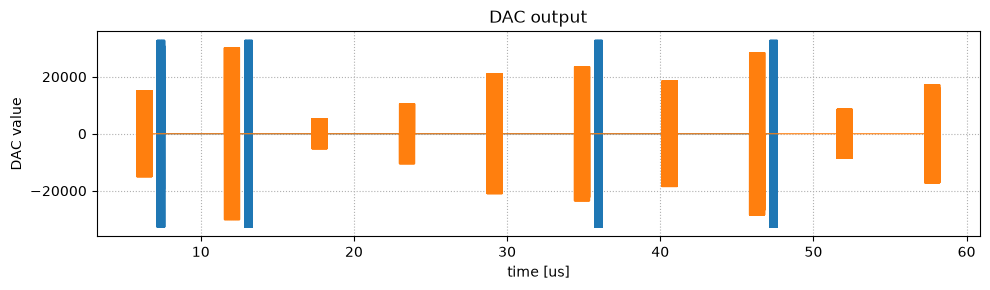

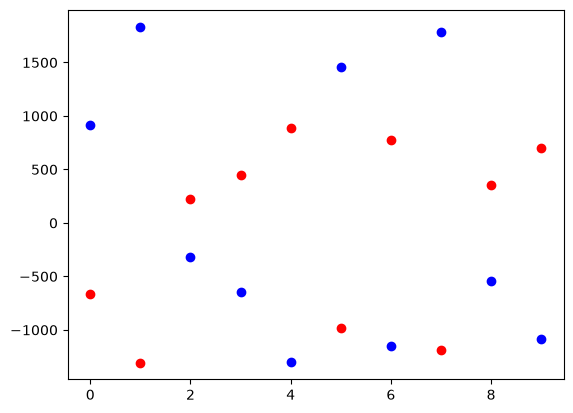

In [6]:
# emulator artifacts
OUT = ARTIFACTS_ROOT / 'hmc_feedback'
OUT.mkdir(parents=True, exist_ok=True)

soc = soc.prepare_emu(memdir=OUT, test_run_ns=75_000, trace=False, verbose=False)
print(f'Artifacts -> {OUT}')

# PERFORMANCE NOTE: build=True (the prepare_emu default) runs `make verilate`,
# a full re-parse and recompile of the Verilog testbench -- the slowest part
# of an emulator run. This notebook only acquires once, so it's harmless
# here, but if you add more prog.acquire() cells below, pass build=False on
# every later prepare_emu() call (or set soc._default_build = False) to
# reuse the compiled binary instead of rebuilding it every time -- see
# 00_intro_emu.ipynb for the full pattern.


soc.tproc.set_lfsr_cfg(2) # set the LFSR to update on a read, more can be found here: https://docs.qick.dev/latest/_autosummary/qick.drivers.tproc.html#qick.drivers.tproc.Axis_QICK_Proc.set_lfsr_cfg

d = prog.acquire(soc=soc, rounds=1)

# Plot DAC waveform
QICKEmu_plot_all_dacs(soc, OUT)

i_data = d[0][0].T[0]
q_data = d[0][0].T[1]
mag = np.sqrt(i_data**2+q_data**2)

plt.plot(q_data, 'ob')
plt.plot(i_data, 'or')

In [7]:
'''
Print program out to show what is going on
'''
print(prog)

macros:
	WriteReg(dst='s_core_w1', src=0)
	AsmInst(inst={'P_ADDR': 0, 'CMD': 'NOP'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 1, 'LINE': 1, 'LIT': '#32766', 'CMD': 'REG_WR', 'DST': 'w3', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 2, 'LINE': 2, 'LIT': '#0', 'CMD': 'REG_WR', 'DST': 'w1', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 3, 'LINE': 3, 'LIT': '#0', 'CMD': 'REG_WR', 'DST': 'w2', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 4, 'LINE': 4, 'LIT': '#599', 'CMD': 'REG_WR', 'DST': 'w4', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 5, 'LINE': 5, 'LIT': '#9', 'CMD': 'REG_WR', 'DST': 'w5', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 6, 'LINE': 6, 'LIT': '#44810940', 'CMD': 'REG_WR', 'DST': 'w0', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 7, 'LINE': 7, 'CMD': 'WMEM_WR', 'DST': '[&0]'}, addr_inc=1)
	AsmInst(inst={'CMD': 'JUMP', 'LABEL': 'END_SETUP'}, addr_inc=1)
	Label(label='playPULSE1')
	AsmInst(inst={'P_ADDR': 0, 'CMD': 'NOP'}, addr_inc=1)
	Asm